In [ ]:
pip install qiskit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 37.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 1.9 MB/s eta 0:00:00


In [ ]:
pip install qiskit_ibm_runtime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.8/386.8 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.5/102.5 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.8/212.8 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 2.5 MB/s eta 0:00:00


In [ ]:
pip install matplotlib pylatexenc


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 3.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=57424cb7ad3d2a57017b85e6fab3c26612ae0539591877fab831ad4c78378a71
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


In [ ]:
pip install qiskit_aer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 82.5 MB/s eta 0:00:00


In [ ]:
pip install 'qiskit[visualization]'

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector, Parameter
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import EstimatorV2 as Estimator
from qiskit_ibm_runtime.fake_provider import FakeAlmadenV2
backend = FakeAlmadenV2()
estimator = Estimator(mode=backend)
#Giving number of shots
estimator.options.default_shots = 10000

/usr/local/lib/python3.12/dist-packages/samplomatic/__init__.py:20: UserWarning: 
You have imported samplomatic==0.18.0 which is in 
beta development. Please expect breaking changes between 
minor versions and pin your dependencies accordingly.
  _warn_once_per_version(


# VQE for 38 Ar 1+ state in JW using COBYLA optimizer and Fake Backend

In [ ]:
hamiltonian = SparsePauliOp.from_list([

     ("IIIIII", -112.474365), ("IIIIXX", 0.069808), ("IIIIYY",  0.069808),

     ("YYYZZY", -0.030228), ("XXXZXI", 0.035436), ("ZIIIZI", -37.316925),

     ("XXXZZX", -0.030228) , ("YYXZZX", -0.030228), ("IIZIII",  37.398754),

     ("YXYZZX", -0.030228), ("XYYZZX", 0.030228), ("IZZIII", -37.398754),

     ("YYYZYI", 0.035436 ), ("YXXZZY",  0.030228) , ("IZIIII", 37.398754 ),

     ("XYXZZY",  -0.030228), ("XXYZZY",-0.030228 ), ("ZIIIII",  75.075611),

     ("YYXZXI",  0.035436), ("YXYZXI",  0.035436), ("ZIIIIZ", -37.758686),

     ("XYYZXI", -0.035436 ), ("YXXZYI", -0.035436), ("IIIIIZ",  37.758686),

     ("XYXZYI", 0.035436 ), ("XXYZYI",  0.035436), ("IIIIZI", 37.316925 )

     ])

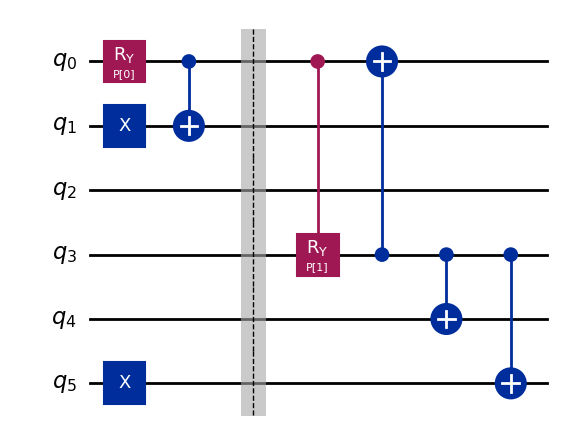

In [ ]:
qc = QuantumCircuit(6)
theta = ParameterVector('P', 2)
qc.x(1)
qc.x(5)
qc.ry(theta[0],0)
qc.cx(0,1)
qc.barrier()
qc.cry(theta[1],0,3)
qc.cx(3,0)
qc.cx(3,4)
qc.cx(3,5)
qc.draw("mpl")

In [ ]:
ansatz = qc
pm = generate_preset_pass_manager(backend=backend, optimization_level=0)
ansatz_isa = pm.run(ansatz)
hamiltonian_isa = hamiltonian.apply_layout(layout=ansatz_isa.layout)
x0 = 2 * np.pi * np.random.random(ansatz.num_parameters)

def cost_func(theta, ansatz, hamiltonian, estimator):
    pub = (ansatz, hamiltonian, [theta])
    result = estimator.run(pubs=[pub]).result()
    energy = result[0].data.evs[0]
    return energy

def minimization(ansatz_isa, hamiltonian_isa, estimator):
    res = minimize(
        cost_func,
        x0,
        args=(ansatz_isa, hamiltonian_isa, estimator),
        method="COBYLA"
    )
    return res.fun

In [ ]:
result = minimization(ansatz_isa, hamiltonian_isa, estimator)
print(result)

-144.43298883140005


In [ ]:

E_runs = []
E_runs.append(result)

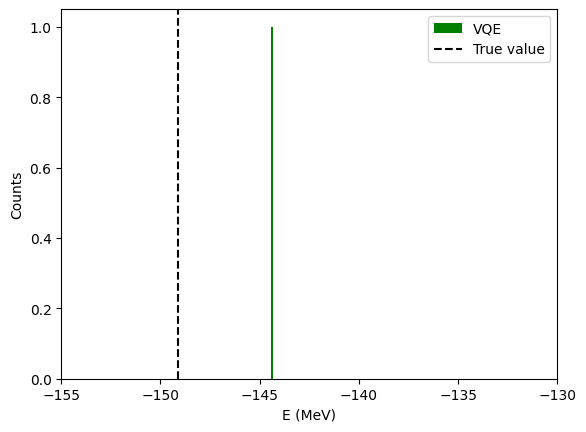

In [ ]:
true_value = -149.104 # (MeV)
plt.hist(np.array(E_runs),label = 'VQE',color = 'green')
plt.xlabel('E (MeV)')
plt.ylabel('Counts')
plt.axvline(x = true_value,ymin = 0,ymax = 1,linestyle = '--',c = 'k',label = 'True value')
plt.xlim(-155,-130)
plt.legend()

# VQE for 38 Ar 1+ state in JW using SPSA optimizer

In [ ]:
ansatz = qc
pm = generate_preset_pass_manager(backend=backend, optimization_level=3)

ansatz_isa = pm.run(ansatz)
hamiltonian_isa = hamiltonian.apply_layout(layout=ansatz_isa.layout)

def cost_func(theta, ansatz, hamiltonian, estimator):

    pub = (ansatz, hamiltonian, [theta])
    result = estimator.run(pubs=[pub]).result()
    energy = result[0].data.evs[0]

    return energy

from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import EstimatorV2 # Ensure EstimatorV2 is imported

# This method is much more memory-efficient for large qubit counts
local_backend = AerSimulator(method='matrix_product_state')
local_estimator = EstimatorV2(mode=local_backend) # Re-initialize estimator with the local backend

x0 = 2 * np.pi * np.random.random(ansatz.num_parameters)
from qiskit_algorithms.optimizers import SPSA
from functools import partial

optimizer = SPSA()

# Create a partial function to bind the fixed arguments, using the local_estimator
objective = partial(cost_func, ansatz=ansatz_isa, hamiltonian=hamiltonian_isa, estimator=local_estimator)

# Call minimize with the wrapped objective function and initial point
result = optimizer.minimize(fun=objective, x0=x0)
print(result.fun)

-149.07258541552736


# VQE + VQD for 38 Ar $1^+$ state in JW using SPSA optimizer

In [ ]:



hamiltonian = SparsePauliOp.from_list([

     ("IIIIII", -112.474365), ("IIIIXX", 0.069808), ("IIIIYY",  0.069808),

     ("YYYZZY", -0.030228), ("XXXZXI", 0.035436), ("ZIIIZI", -37.316925),

     ("XXXZZX", -0.030228) , ("YYXZZX", -0.030228), ("IIZIII",  37.398754),

     ("YXYZZX", -0.030228), ("XYYZZX", 0.030228), ("IZZIII", -37.398754),

     ("YYYZYI", 0.035436 ), ("YXXZZY",  0.030228) , ("IZIIII", 37.398754 ),

     ("XYXZZY",  -0.030228), ("XXYZZY",-0.030228 ), ("ZIIIII",  75.075611),

     ("YYXZXI",  0.035436), ("YXYZXI",  0.035436), ("ZIIIIZ", -37.758686),

     ("XYYZXI", -0.035436 ), ("YXXZYI", -0.035436), ("IIIIIZ",  37.758686),

     ("XYXZYI", 0.035436 ), ("XXYZYI",  0.035436), ("IIIIZI", 37.316925 )

     ])

qc = QuantumCircuit(6)
theta = ParameterVector('P', 2)
qc.x(1)
qc.x(5)
qc.ry(theta[0],0)
qc.cx(0,1)
qc.barrier()
qc.cry(theta[1],0,3)
qc.cx(3,0)
qc.cx(3,4)
qc.cx(3,5)
ansatz = qc



In [ ]:
pip install qiskit_algorithms

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 5.7 MB/s eta 0:00:00


In [ ]:
from qiskit.primitives import StatevectorSampler, StatevectorEstimator
from qiskit_algorithms.state_fidelities import ComputeUncompute
from qiskit_algorithms.utils import algorithm_globals
from qiskit_algorithms.optimizers import SPSA
optimizer = SPSA()

algorithm_globals.random_seed = 42

estimator = StatevectorEstimator(seed=42)
sampler = StatevectorSampler(seed=42)
fidelity = ComputeUncompute(sampler)
k = 1
counts = []
values = []
steps = []

def callback(eval_count, theta, value, meta, step):
    counts.append(eval_count)
    values.append(value)
    steps.append(step)

from qiskit_algorithms import VQD

vqd = VQD(estimator, fidelity, ansatz, optimizer, k=k, callback=callback)
result = vqd.compute_eigenvalues(operator=hamiltonian)
vqd_values = result.eigenvalues


In [ ]:
print(vqd_values.real)

[-151.09317243]


# VQE for 38 Ar 2+ state in JW using COBYLA optimizer and Fake Backend

In [ ]:
hamiltonian = SparsePauliOp.from_list([
    ("IIIIII", -75.198364), ("ZIZIII", -37.439678), ("IIZIII", 37.439678),

    ("IXXIII",  0.139617), ("IZIIII",  37.758686 ), ("ZIIIII",  75.198364),

    ("IYYIII",  0.139617), ("ZZIIII",  -37.758686 )

])

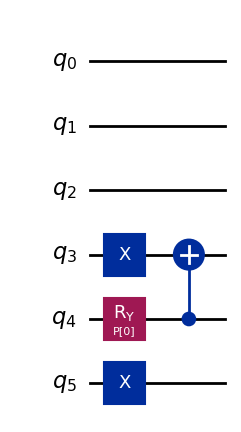

In [ ]:
qc = QuantumCircuit(6)
theta = ParameterVector('P', 1)
qc.x(3)
qc.x(5)
qc.ry(theta[0],4)
qc.cx(4,3)
qc.draw("mpl")

In [ ]:
ansatz = qc
pm = generate_preset_pass_manager(backend=backend, optimization_level=3)

ansatz_isa = pm.run(ansatz)
hamiltonian_isa = hamiltonian.apply_layout(layout=ansatz_isa.layout)

def cost_func(theta, ansatz, hamiltonian, estimator):

    pub = (ansatz, hamiltonian, [theta])
    result = estimator.run(pubs=[pub]).result()
    energy = result[0].data.evs[0]

    return energy


x0 = 2 * np.pi * np.random.random(ansatz.num_parameters)
# Minimization function for Hamiltonian
def minimization(ansatz_isa, hamiltonian_isa, estimator):

    res = minimize(
        cost_func,
        x0,
        args=(ansatz_isa, hamiltonian_isa, estimator),
        method="COBYLA"
    )
    return res.fun

In [ ]:
result = minimization(ansatz_isa, hamiltonian_isa, estimator)
print(result)

-151.09317329053482


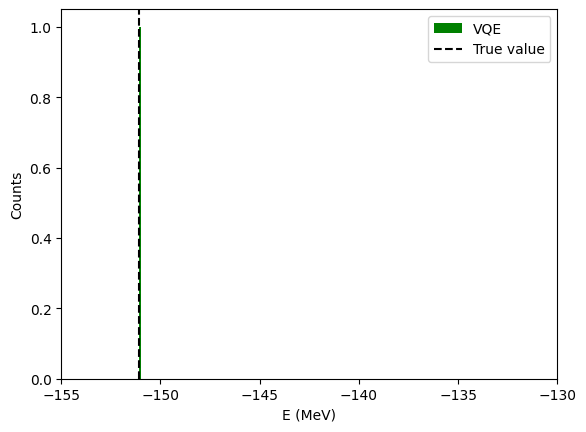

In [ ]:
E_runs = []
E_runs.append(result)
true_value = -151.093 # (MeV)
plt.hist(np.array(E_runs),label = 'VQE',color = 'green')
plt.xlabel('E (MeV)')
plt.ylabel('Counts')
plt.axvline(x = true_value,ymin = 0,ymax = 1,linestyle = '--',c = 'k',label = 'True value')
plt.xlim(-155,-130)
plt.legend()


# VQE for 38 Ar 2+ state in JW using SPSA optimizer

In [ ]:
ansatz = qc
pm = generate_preset_pass_manager(backend=backend, optimization_level=3)

ansatz_isa = pm.run(ansatz)
hamiltonian_isa = hamiltonian.apply_layout(layout=ansatz_isa.layout)

def cost_func(theta, ansatz, hamiltonian, estimator):

    pub = (ansatz, hamiltonian, [theta])
    result = estimator.run(pubs=[pub]).result()
    energy = result[0].data.evs[0]

    return energy

from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import EstimatorV2 # Ensure EstimatorV2 is imported

# This method is much more memory-efficient for large qubit counts
local_backend = AerSimulator(method='matrix_product_state')
local_estimator = EstimatorV2(mode=local_backend) # Re-initialize estimator with the local backend

x0 = 2 * np.pi * np.random.random(ansatz.num_parameters)
from qiskit_algorithms.optimizers import SPSA
from functools import partial

optimizer = SPSA()

# Create a partial function to bind the fixed arguments, using the local_estimator
objective = partial(cost_func, ansatz=ansatz_isa, hamiltonian=hamiltonian_isa, estimator=local_estimator)

# Call minimize with the wrapped objective function and initial point
result = optimizer.minimize(fun=objective, x0=x0)
print(result.fun)

-151.09831799316407


# VQE + VQD for 38 Ar $2^+$ state in JW using SPSA optimizer

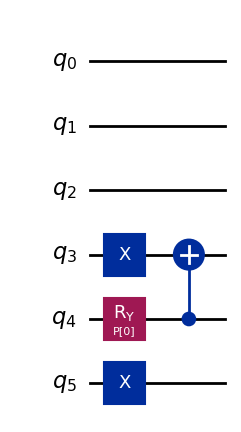

In [ ]:
hamiltonian = SparsePauliOp.from_list([
    ("IIIIII", -75.198364), ("ZIZIII", -37.439678), ("IIZIII", 37.439678),

    ("IXXIII",  0.139617), ("IZIIII",  37.758686 ), ("ZIIIII",  75.198364),

    ("IYYIII",  0.139617), ("ZZIIII",  -37.758686 )

])

qc = QuantumCircuit(6)
theta = ParameterVector('P', 1)
qc.x(3)
qc.x(5)
qc.ry(theta[0],4)
qc.cx(4,3)
qc.draw("mpl")




In [ ]:
ansatz = qc
from qiskit.primitives import StatevectorSampler, StatevectorEstimator
from qiskit_algorithms.state_fidelities import ComputeUncompute
from qiskit_algorithms.utils import algorithm_globals
from qiskit_algorithms.optimizers import COBYLA
optimizer = COBYLA()

algorithm_globals.random_seed = 42

estimator = StatevectorEstimator(seed=42)
sampler = StatevectorSampler(seed=42)
fidelity = ComputeUncompute(sampler)
k = 2
counts = []
values = []
steps = []

def callback(eval_count, theta, value, meta, step):
    counts.append(eval_count)
    values.append(value)
    steps.append(step)

from qiskit_algorithms import VQD
vqd = VQD(estimator, fidelity, ansatz, optimizer, k=k, callback=callback)
result = vqd.compute_eigenvalues(operator=hamiltonian)
vqd_values = result.eigenvalues

In [ ]:
print(vqd_values.real)

[-151.09317329 -149.70200034]
